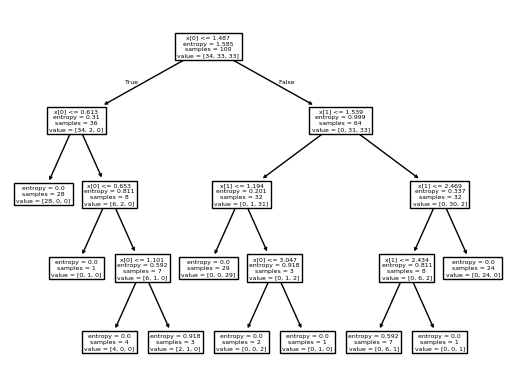

Accuracy 0.98
Confusion Matrix
[[34  0  0]
 [ 1 32  0]
 [ 0  1 32]]
F1 0.98


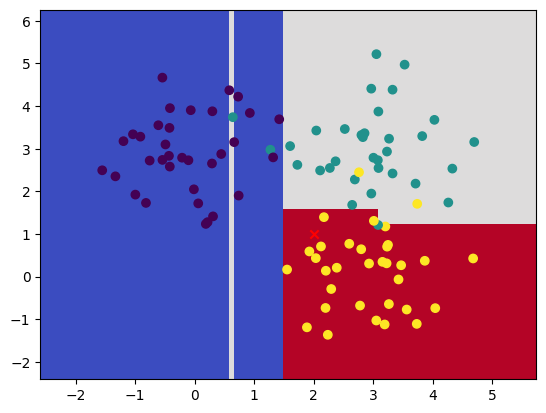

In [53]:
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from matplotlib import pyplot as plt

X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)],
                                      n_features=2, random_state=42,
                                      cluster_std=(0.9,0.9,0.9))

depth = 4

def model(X, y, depth):
    clf_tree = DecisionTreeClassifier(criterion='entropy' ,max_depth=depth, random_state=42)
    clf_tree.fit(X, y)

    tree.plot_tree(clf_tree)
    # print(tree.export_text(clf_tree))
    plt.show()

    X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
    X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)

    y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
    plt.pcolormesh(X0_grid, X1_grid, y_predict, cmap='coolwarm')

    plt.scatter(X[:, 0], X[:, 1], c=y)


    y_predict = clf_tree.predict(X)

    print('Accuracy', clf_tree.score(X, y))
    print('Confusion Matrix')
    print(confusion_matrix(y, y_predict))
    print('F1', metrics.f1_score(y, y_predict,  average='micro'))

    observation_new = [[2, 1]]

    new = clf_tree.predict(observation_new)

    plt.scatter(observation_new[0][0], observation_new[0][1], marker='x', c='red')
    plt.show()
model(X, y, depth)

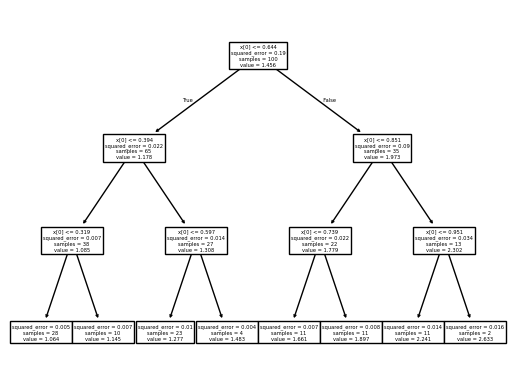

r2=  0.9571131119191985
MSE=  0.008144548299279188


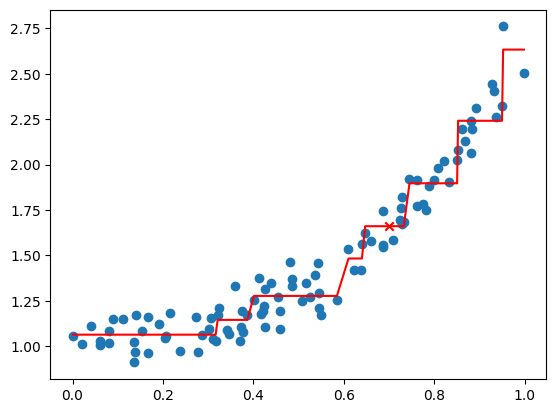

In [41]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])

X_ = X.reshape(-1, 1)
depth=3
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
reg_tree.fit(X_, y)
y_pred_reg = reg_tree.predict(X_)

tree.plot_tree(reg_tree)
plt.show()

plt.scatter(X, y)
plt.plot(X_, y_pred_reg, c='red')

print('r2= ', metrics.r2_score(y, y_pred_reg))
print('MSE= ', metrics.mean_squared_error(y, y_pred_reg))

observation_new = [[0.7]]
new = reg_tree.predict(observation_new)

plt.scatter(observation_new[0][0], new, marker='x', c='red')
plt.show()


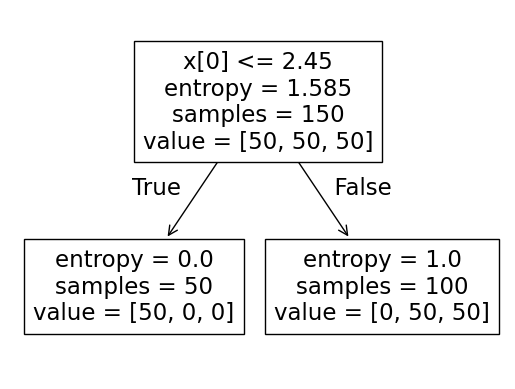

Accuracy 0.6666666666666666
Confusion Matrix
[[50  0  0]
 [ 0 50  0]
 [ 0 50  0]]
F1 0.6666666666666666


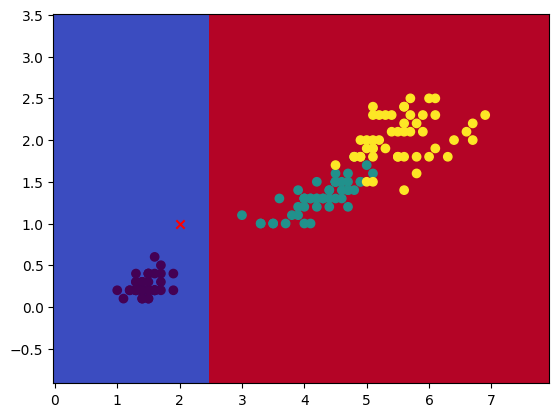

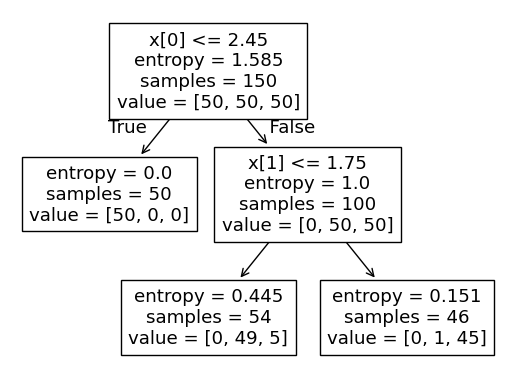

Accuracy 0.96
Confusion Matrix
[[50  0  0]
 [ 0 49  1]
 [ 0  5 45]]
F1 0.96


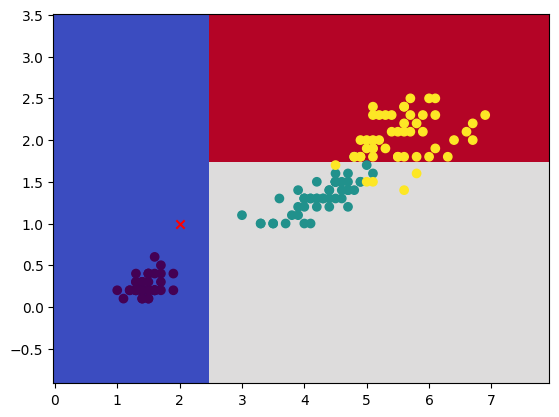

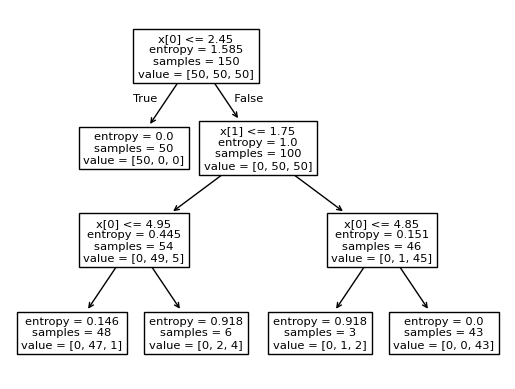

Accuracy 0.9733333333333334
Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]
F1 0.9733333333333334


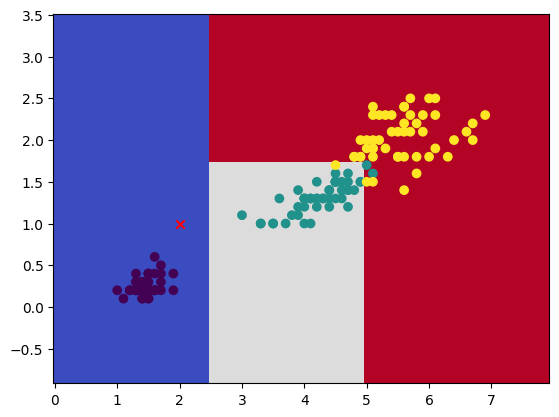

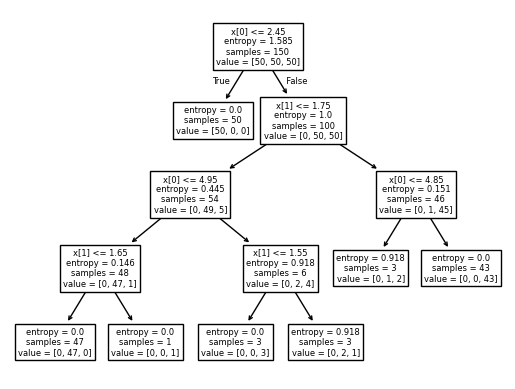

Accuracy 0.9866666666666667
Confusion Matrix
[[50  0  0]
 [ 0 49  1]
 [ 0  1 49]]
F1 0.9866666666666667


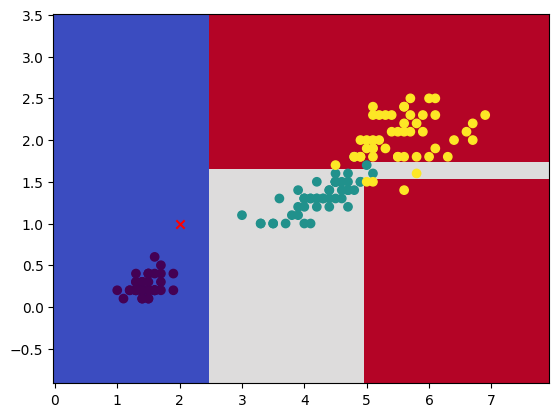

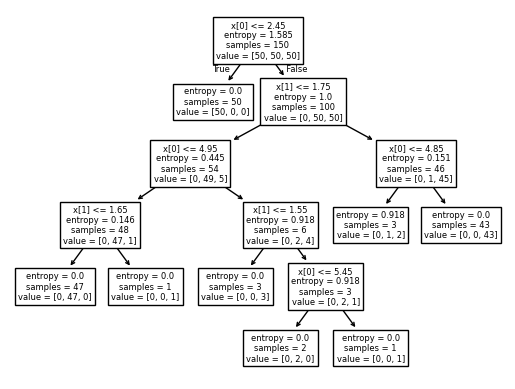

Accuracy 0.9933333333333333
Confusion Matrix
[[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]
F1 0.9933333333333333


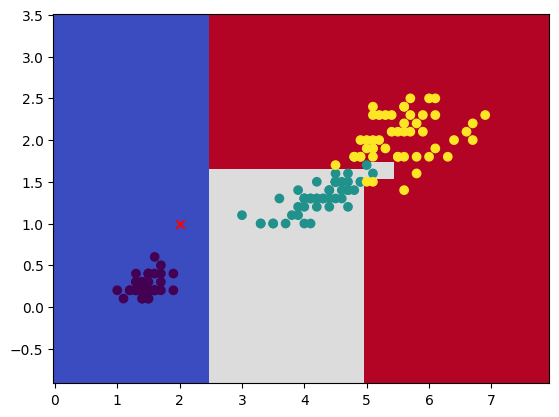

In [55]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data[:, 2:]
y = iris.target

for depth in [1, 2, 3, 4, 10]:
    model(X, y, depth)

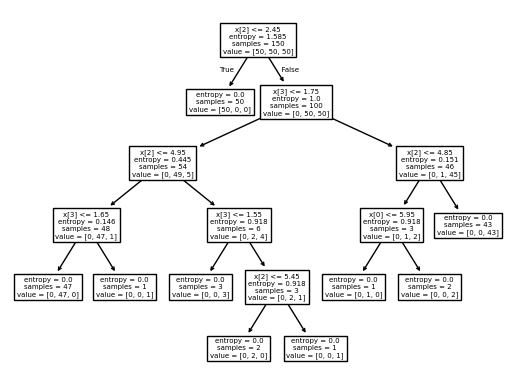

Accuracy 1.0
Confusion Matrix
[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]
F1 1.0


In [57]:
X = iris.data
y = iris.target

clf_tree_iris_all = DecisionTreeClassifier(criterion='entropy' ,max_depth=depth, random_state=42)
clf_tree_iris_all.fit(X, y)

tree.plot_tree(clf_tree_iris_all)
# print(tree.export_text(clf_tree_iris_all))
plt.show()

y_predict = clf_tree_iris_all.predict(X)

print('Accuracy', clf_tree_iris_all.score(X, y))
print('Confusion Matrix')
print(confusion_matrix(y, y_predict))
print('F1', metrics.f1_score(y, y_predict,  average='micro'))

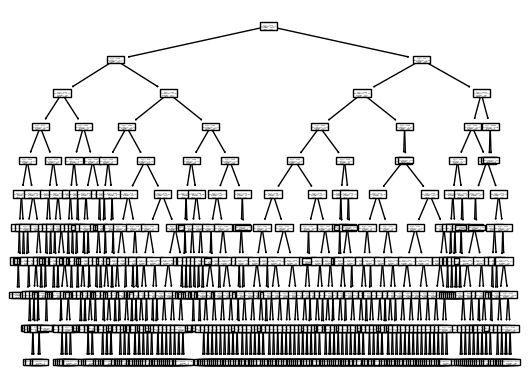

r2=  0.04490146463176692
MSE=  1.2717617413772655


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


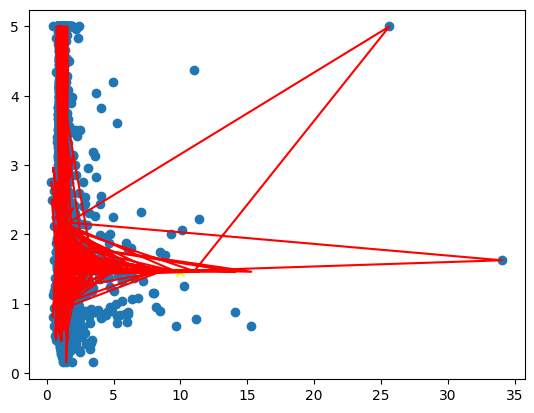

In [83]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

X = df[['AveBedrms']]
y = data.target

reg_tree = DecisionTreeRegressor(max_depth=10 ,random_state=0)
reg_tree.fit(X, y)
y_pred_reg = reg_tree.predict(X)

tree.plot_tree(reg_tree)
plt.show()

plt.scatter(X, y)
plt.plot(X, y_pred_reg, c='red')

print('r2= ', metrics.r2_score(y, y_pred_reg))
print('MSE= ', metrics.mean_squared_error(y, y_pred_reg))

observation_new = [[10]]
new = reg_tree.predict(observation_new)

plt.scatter(observation_new[0][0], new, marker='x', c='yellow')
plt.show()

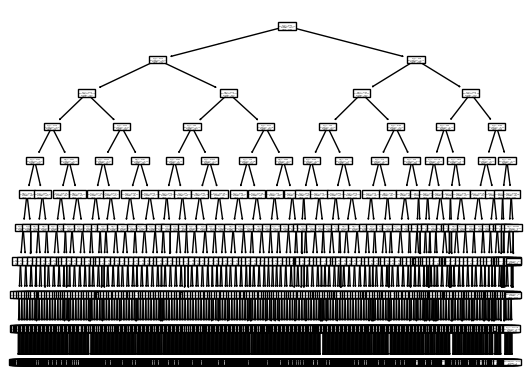

r2=  0.8206970165223321
MSE=  0.23875094145525205


In [98]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

X = df
y = data.target

reg_tree = DecisionTreeRegressor(max_depth=10 ,random_state=0)
reg_tree.fit(X, y)
y_pred_reg = reg_tree.predict(X)

tree.plot_tree(reg_tree)
plt.show()

print('r2= ', metrics.r2_score(y, y_pred_reg))
print('MSE= ', metrics.mean_squared_error(y, y_pred_reg))